In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affiche toutes les lignes
pd.set_option('display.max_rows', None)

# Affiche toutes les colonnes
pd.set_option('display.max_columns', None)
# Choisis le nombre de caractère par colonnes
pd.set_option('display.max_colwidth', 50)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler, KBinsDiscretizer, OneHotEncoder

from sklearn.feature_selection import SelectKBest, f_regression

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.model_selection import learning_curve, cross_validate, KFold

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [5]:
def import_data():
    data_path = 'washington_ultimate.csv'
    data = pd.read_csv(data_path)
    #
    return data

In [6]:
def first_cleaning(data):
    data = data.drop(columns=['list_to_sold_ratio', 'price_per_sqft','baths_full_calc'])
    #
    data = data.dropna(subset=['lastSoldPrice'])
    #
    return data

In [7]:
def add_dataset(data):
    data_path = 'uszips.csv'
    loc_data = pd.read_csv(data_path)
    loc_data = loc_data[['zip', 'population']]
    #
    data = pd.merge(data, loc_data, on='zip', how='left', )
    #
    return data

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin

In [9]:
class FillNanByGroup(BaseEstimator, TransformerMixin):
    def __init__(self, fill_error_col, fill_median_col, condition_col='type', condition_value='land'):
        self.condition_col = condition_col
        self.condition_value = condition_value
        self.fill_error_col = fill_error_col
        self.fill_median_col = fill_median_col
        self.group_medians_ = {}
        self.global_medians_ = {}

    def set_output(self, transform=None):
        """
        Permet à scikit-learn de savoir que ce transformateur gère nativement 
        les DataFrames pandas et ne nécessite pas de conversion spéciale.
        """
        return self
            

    def fit(self, X, y=None):
        # 1. Déduction automatique : Toutes les colonnes SAUF celle du groupe
        self.fill_median = self.fill_error_col + self.fill_median_col
        
        # 2. Calcul des médianes sur les colonnes déduites
        for col in self.fill_median:
            group_median_series = X.groupby(self.condition_col)[col].median()
            self.group_medians_[col] = group_median_series.to_dict()
            self.global_medians_[col] = X[col].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        #
        ###############
        mask = X[self.condition_col] == self.condition_value
        for col in self.fill_error_col:
            X.loc[mask, col] = X.loc[mask, col].fillna(0)
        #
        ###############
        for col in self.fill_median:
            group_map = self.group_medians_[col]
            global_val = self.global_medians_[col]
            
            mapped_medians = X[self.condition_col].map(group_map)
            X[col] = X[col].fillna(mapped_medians)
            X[col] = X[col].fillna(global_val)
        #
        #
        return X

In [10]:
def cat_zip(X):
    X = X.copy()
    #
    def cat_zip(row):
        zip_code = str(row['zip'])
        #
        #  Mégalopole urbaine et technologique
        if zip_code.startswith(('980', '981', '982')):
            return 'puget_sound_core'
        # Zones portuaires, capitale d'état, et côte Pacifique
        elif zip_code.startswith(('983', '985', '986')):
            return 'south_and_coast'
        # Vallées agricoles et viticoles
        elif zip_code.startswith(('988', '989')):
            return 'central_valleys'
        # Seconde métropole de l'état
        elif zip_code.startswith(('990', '992', '993')):
            return 'spokane_inland_empire'
        # Autres zones peu peuplées
        elif zip_code.startswith(('98', '99')) :
            return 'other'
    
    X['zip_category'] = X.apply(cat_zip, axis=1)

    X = X.drop(columns=['zip'])

    return X

zip_category_function = FunctionTransformer(cat_zip)

In [11]:
from nltk import tokenize

In [12]:
def count_text(X):
    X = X.copy()
    #
    def word_count(review):
        if isinstance(review, str):
            return len(review.split())
        return 0 

    X['length_text'] = X['sanitized_text'].str.len()
    X['length_text'] = X['length_text'].fillna(0)

    X['word_count_text'] = X['sanitized_text'].apply(word_count)

    X['mean_word_length_text'] = X['sanitized_text'].map(
        lambda rev: np.mean([len(word) for word in rev.split()]) if isinstance(rev, str) else 0
    )

    X['mean_sent_length_text'] = X['sanitized_text'].map(
        lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]) if isinstance(rev, str) else 0
        )
    
    X = X.drop(columns=['sanitized_text'])
    
    return X

count_text_function = FunctionTransformer(count_text)

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
error_col = ['stories', 'beds', 'baths', 'baths_full', 'garage']
median_col = ['year_built', 'listPrice', 'sqft']
condition_col = ['type']
zip_col = ['zip']
pop_col = ['population']
text_col = ['sanitized_text']


fill_median_pipe = Pipeline([
    ('impute_median_group', FillNanByGroup(fill_error_col=error_col, fill_median_col=median_col)),
])

fill_zip_pipe = Pipeline([
    ('impute_mode', SimpleImputer(strategy='most_frequent')),
])

fill_population_pipe = Pipeline([
    ('fix_population', SimpleImputer(strategy='constant', fill_value=114000.0)), # A modifier pour être utilisable sur tout type de NaN
])

fill_text_pipe = Pipeline([
    ('fix_population', SimpleImputer(strategy='constant', fill_value="")), # A modifier pour être utilisable sur tout type de NaN
])

fillna_pipeline = ColumnTransformer([
    ('fill_median', fill_median_pipe, error_col + median_col + condition_col),
    ('fill_zip', fill_zip_pipe, zip_col),
    ('fill_pop', fill_population_pipe, pop_col),
    #('fill_text', fill_text_pipe, text_col),
], remainder='passthrough', verbose_feature_names_out=False)

fillna_pipeline.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('fill_median', ...), ('fill_zip', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [15]:
feature_engineering_pipeline = Pipeline([
    ('cat_zip', zip_category_function),
    ('count_text', count_text_function),
])

feature_engineering_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cat_zip', ...), ('count_text', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cat...0018C4B9700E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass 

In [16]:
scaler_col = ['year_built', 'listPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'garage',
             'population', 'length_text', 'word_count_text', 'mean_word_length_text', 'mean_sent_length_text']
#
#
scaler_pipe = Pipeline(steps=[('scaler', RobustScaler()),])
#
#
onehot_col = ['type', 'zip_category']
#
onehot_pipe = Pipeline([('onehot_encod', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.02, sparse_output=False))]) 

scale_encod_pipeline = ColumnTransformer([
    ('scale_num', scaler_pipe, scaler_col),
    ('encod_cat', onehot_pipe, onehot_col),
], remainder='passthrough')

scale_encod_pipeline.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale_num', ...), ('encod_cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

In [17]:
def model_evaluation(X_train, y_train, pipe, cv):
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2',
            'MedianAE': 'neg_median_absolute_error'
        },
        return_train_score=False,
        n_jobs=-1
    )

    return cv_scores

In [18]:
def model_learning_curve(X_train, y_train, pipe, cv):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
    )

    return train_sizes, train_scores, val_scores


def learning_curve_plot(lc_data):
    n_models = len(lc_data)
    cols = 3
    rows = int(np.ceil(n_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for ax, data in zip(axes, lc_data):

        size = data['t_size']
        tscore = data['t_score']
        vscore = data['v_score']

        train_scores_mean = -tscore.mean(axis=1)
        val_scores_mean = -vscore.mean(axis=1)

        ax.plot(size, train_scores_mean, marker='o', label='Train MAE')
        ax.plot(size, val_scores_mean, marker='o', label='Validation MAE')

        ax.set_title(data['model'])
        ax.grid(True)

        ax.legend()

    plt.tight_layout()
    plt.show()

In [19]:
df = import_data()
df = first_cleaning(df)
df = add_dataset(df)

In [20]:
target = 'lastSoldPrice'

X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [22]:
models = {
    'linear_regression': LinearRegression(),
    'ridge': Ridge(),
    'lasso': Lasso(),
    'elasticnet': ElasticNet(),
    'svr': SVR(),
    'random_forest': RandomForestRegressor(random_state=0),
    'gradient_boosting': GradientBoostingRegressor(random_state=0),
    'xgboost': XGBRegressor(random_state=0),
}

In [23]:
results = []

for model_name, model in models.items():
    full_pipe = Pipeline([
        ('fillnan', fillna_pipeline),
        ('feature_engineering', feature_engineering_pipeline),
        ('scale_encod', scale_encod_pipeline),
        ('model', model)
    ])

    cv_scores = model_evaluation(X_train, y_train, full_pipe, cv)

    results.append({
        'model': model_name,
        'MAE_mean': -cv_scores['test_MAE'].mean(),
        'RMSE_mean': -cv_scores['test_RMSE'].mean(),
        'R2_mean': cv_scores['test_R2'].mean(),
    })

results_df = pd.DataFrame(results).sort_values('MAE_mean').reset_index(drop=True)
print(results_df)

               model       MAE_mean      RMSE_mean   R2_mean
0      random_forest   75153.964582  352063.762444  0.746643
1            xgboost   83222.069236  355281.526201  0.735804
2  gradient_boosting  102718.455407  357383.319544  0.738726
3         elasticnet  159610.281241  488419.370109  0.521288
4              ridge  165396.008144  478232.083330  0.540249
5              lasso  165425.759659  478242.268451  0.540227
6  linear_regression  165428.951841  478242.847900  0.540226
7                svr  357631.418212  720088.240009 -0.053450


In [24]:
models = {
    'linear_regression': LinearRegression(),
    'ridge': Ridge(),
}

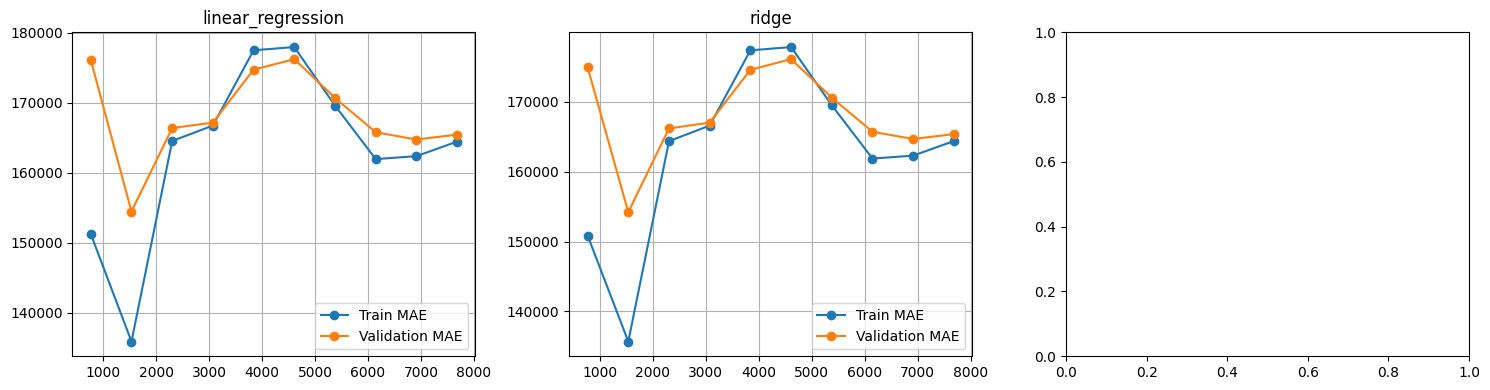

In [25]:
lc_data = []

for model_name, model in models.items():
    full_pipe = Pipeline([
        ('fillnan', fillna_pipeline),
        ('feature_engineering', feature_engineering_pipeline),
        ('scale_encod', scale_encod_pipeline),
        ('model', model)
    ])

    train_sizes, train_scores, val_scores = model_learning_curve(X_train, y_train, full_pipe, cv)

    lc_data.append({
        'model': model_name,
        't_size': train_sizes,
        't_score': train_scores,
        'v_score': val_scores
    })

learning_curve_plot(lc_data)